# Appendix A: Computational Complexity

**Source Span.** `Discrete and Computational Geometry, 2nd Edition.pdf`, Appendix A, printed pages 253-258 (PDF pages 268-273).

This appendix is the course's measuring instrument. Earlier chapters build polygons, hulls, triangulations, Voronoi diagrams, reconstructions, linkages, and polyhedra; Appendix A teaches how to ask how much computation those constructions cost as the input size grows. The goal here is not to memorize a list of names. The goal is to read a geometric algorithm and know which part of the construction controls the running time, which lower bound would make the analysis tight, and when a problem has crossed from algorithm design into complexity evidence.

The notebook uses original examples and small computational experiments. It does not reproduce the appendix text; instead it turns the appendix's concepts into plots, comparison ledgers, and sanity checks that connect back to the book's chapters.


## Visual Storyboard

1. **Growth ladder.** Plot the common orders from constant through exponential on shared linear and logarithmic scales, then store sample values so the hierarchy is inspectable rather than rhetorical.
2. **Crossover lab.** Compare a large-constant `n log n` term with a small-constant quadratic term. This mirrors the appendix's warning that constants can dominate for moderate inputs while the highest-order term wins eventually.
3. **Upper, lower, and tight bounds.** Use a compact ledger to distinguish an algorithm's upper bound from a problem lower bound and from a matched asymptotically optimal analysis.
4. **Hardness map.** Draw the proof logic around P, NP, NP-complete, NP-hard, reductions, graph coloring, chain folding, and the real-algebraic class that now appears in geometric guard problems.
5. **Course complexity ledger.** Tie the appendix back to every chapter so a learner can ask, for each construction, what input is being counted and which algorithmic bottleneck matters.

Every visual has an invariant check: monotonic growth samples, a computed crossover index, graph reachability in the reduction map, and a chapter ledger with all seven chapters represented.


In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display, Markdown

BOOK_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'AGENTS.md').exists() and (candidate / 'source_map.json').exists()
)
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import chapter_artifact_root, save_json, save_csv, save_matplotlib, assert_artifacts, display_artifact

UNIT_KEY = 'appendix-a-computational-complexity'
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / 'figures'
TABLES = ARTIFACT_ROOT / 'tables'
CHECKS = ARTIFACT_ROOT / 'checks'
artifact_paths = []

plt.rcParams.update({'figure.figsize': (8, 5), 'axes.grid': True})
print(f'Book root: {BOOK_ROOT}')
print(f'Artifact root: {ARTIFACT_ROOT}')


Book root: D:\Geometry\Discrete-and-Computational-Geometry
Artifact root: D:\Geometry\Discrete-and-Computational-Geometry\artifacts\appendix-a-computational-complexity


## Translation Guide

`n` is always the input size, but geometry forces us to say what the input is. In a hull problem, `n` might be the number of points. In a polygon problem, it might be the number of vertices. In a chain problem, it can be the number of links, while the dimension of configuration space may also depend on degrees of freedom. Complexity statements become meaningful only after that modeling choice is explicit.

Big-O is an upper promise: a running time eventually stays below a constant multiple of a comparison function. Big-Omega is the lower-bound companion: some task or input family forces every algorithm in the chosen model to spend at least that much work. A tight analysis happens when the best upper and lower bounds meet. This is why a chapter can present both an algorithm and a lower-bound argument; the first is a construction, the second is a statement about all possible constructions under a model of computation.

The appendix also separates tractable polynomial behavior from harder evidence. Problems in P have polynomial-time algorithms. NP contains problems whose proposed solutions can be verified in polynomial time. NP-complete and NP-hard labels are usually obtained by polynomial reductions from known hard problems. For geometry, one further warning matters: some guard-placement questions live naturally over real coordinates and are now known to fit a real-algebraic hardness class. That means a purely combinatorial search picture can miss the difficulty introduced by irrational coordinates.


## Library Routing

| Concept | Representation | Library | Why this fit |
| --- | --- | --- | --- |
| Growth classes | linear/log plots and sampled CSV | NumPy, Matplotlib | Direct numeric comparison makes dominance and scale visible. |
| Crossover constants | exact integer scan plus plot | NumPy, JSON checks | The appendix's example is a computational threshold question. |
| Reductions and complexity classes | directed graph | NetworkX, Matplotlib | Reductions are arrows; reachability is the right invariant. |
| Chapter algorithm ledger | table and rank plot | CSV, Matplotlib | The appendix only works as a course tool if it routes back to chapters. |
| Final verification | artifact and invariant assertions | course `utils.artifacts` | Keeps generated paths book-local and checks reproducible. |


## Growth Classes as a Ladder

The first visual deliberately uses the same sample inputs for every class. On a linear scale the exponential curve quickly overwhelms the rest; on a logarithmic scale the polynomial hierarchy becomes easier to compare. The point is not that every `O(n^2)` algorithm is worse than every `O(n log n)` algorithm on every practical machine. The point is that once `n` is large enough and constants are fixed, the order class predicts which term eventually controls the computation.


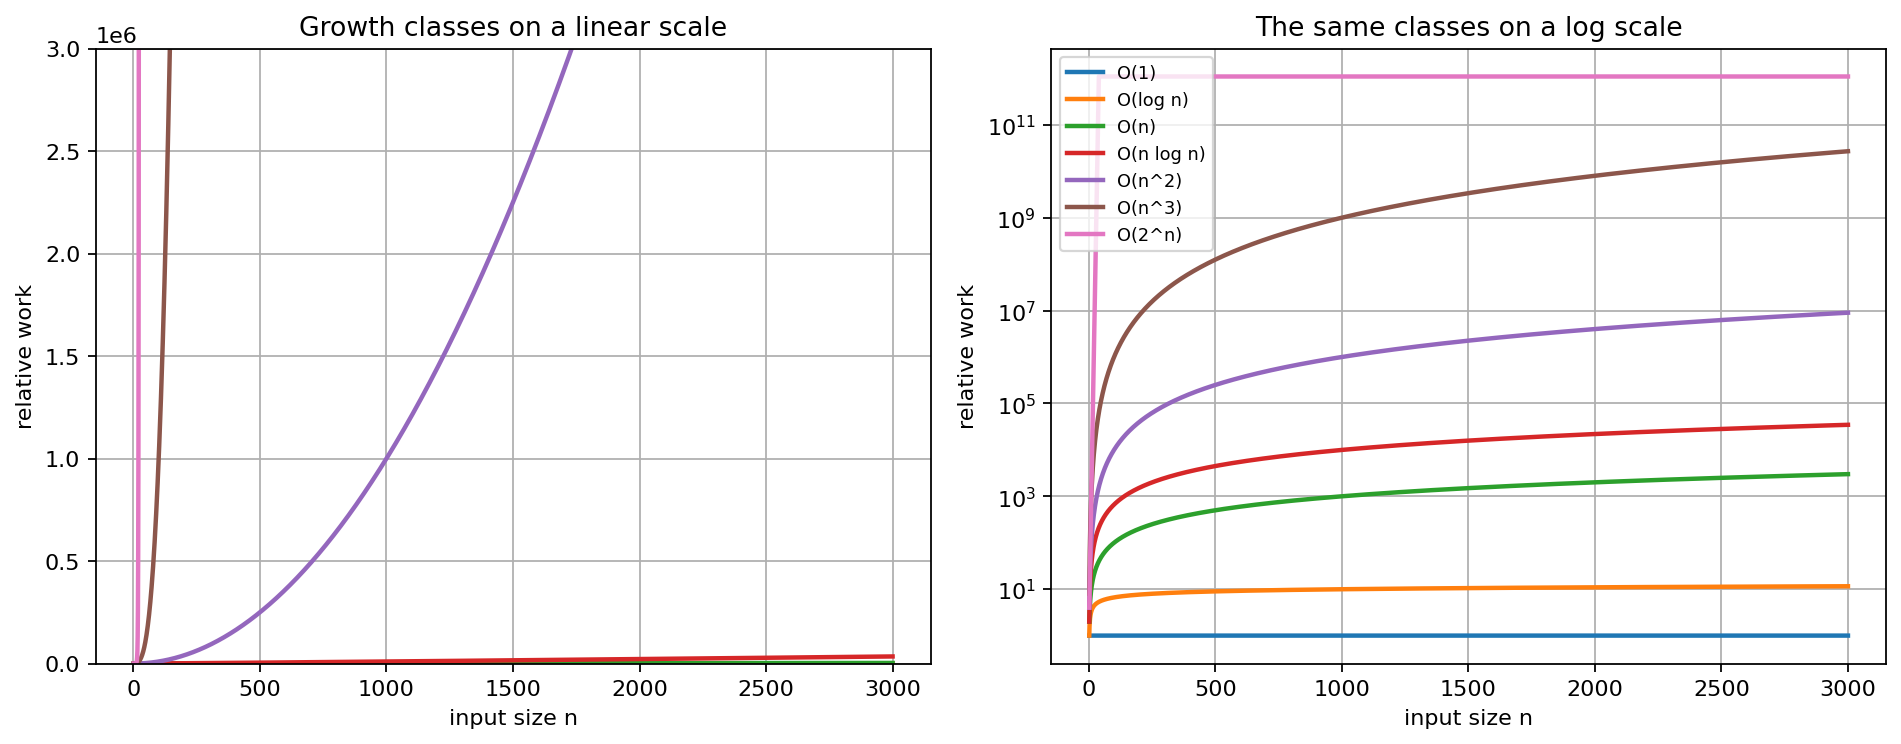

Growth samples: `artifacts\appendix-a-computational-complexity\tables\complexity-growth-samples.csv`

In [2]:
n = np.arange(2, 3001, dtype=float)
orders = {
    'O(1)': np.ones_like(n),
    'O(log n)': np.log2(n),
    'O(n)': n,
    'O(n log n)': n * np.log2(n),
    'O(n^2)': n**2,
    'O(n^3)': n**3,
    'O(2^n)': 2.0 ** np.minimum(n, 40),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for label, values in orders.items():
    if label == 'O(2^n)':
        axes[0].plot(n[n <= 40], values[n <= 40], label=label, linewidth=2)
    else:
        axes[0].plot(n, values, label=label, linewidth=2)
    axes[1].plot(n, np.maximum(values, 1), label=label, linewidth=2)
axes[0].set_title('Growth classes on a linear scale')
axes[0].set_xlabel('input size n')
axes[0].set_ylabel('relative work')
axes[0].set_ylim(0, 3_000_000)
axes[1].set_title('The same classes on a log scale')
axes[1].set_xlabel('input size n')
axes[1].set_ylabel('relative work')
axes[1].set_yscale('log')
axes[1].legend(loc='upper left', fontsize=8)
fig.tight_layout()

growth_plot = save_matplotlib(fig, FIGURES / 'complexity-growth-ladder.png')
plt.close(fig)
artifact_paths.append(growth_plot)

growth_rows = []
for sample in [10, 100, 1000, 3000]:
    row = {'n': sample}
    for label in ['O(1)', 'O(log n)', 'O(n)', 'O(n log n)', 'O(n^2)', 'O(n^3)']:
        row[label] = float(np.interp(sample, n, orders[label]))
    growth_rows.append(row)
growth_table = save_csv(growth_rows, TABLES / 'complexity-growth-samples.csv')

growth_check = {
    'source_span': 'Appendix A, printed pages 253-258',
    'sample_n': 3000,
    'large_n_ordering': ['O(1)', 'O(log n)', 'O(n)', 'O(n log n)', 'O(n^2)', 'O(n^3)'],
    'monotone_checks': {
        label: bool(np.all(np.diff(values[:1000]) >= -1e-9))
        for label, values in orders.items() if label != 'O(1)'
    },
}
growth_check_path = save_json(growth_check, CHECKS / 'big-oh-growth-checks.json')
artifact_paths.extend([growth_table, growth_check_path])

display_artifact(growth_plot, width=900)
display(Markdown(f'Growth samples: `{growth_table.relative_to(BOOK_ROOT)}`'))


## Crossover Lab: Constants Matter Until They Do Not

The appendix gives a concrete style of comparison: one term has a large constant and order `n log n`, while the other has a tiny constant and order `n^2`. The base of the logarithm changes the numeric threshold, so this notebook states its convention explicitly. The cell below uses natural logarithm for the exact scan and stores nearby values, then the discussion explains the robust lesson: constants and lower-order terms decide small cases, but the quadratic term eventually dominates.


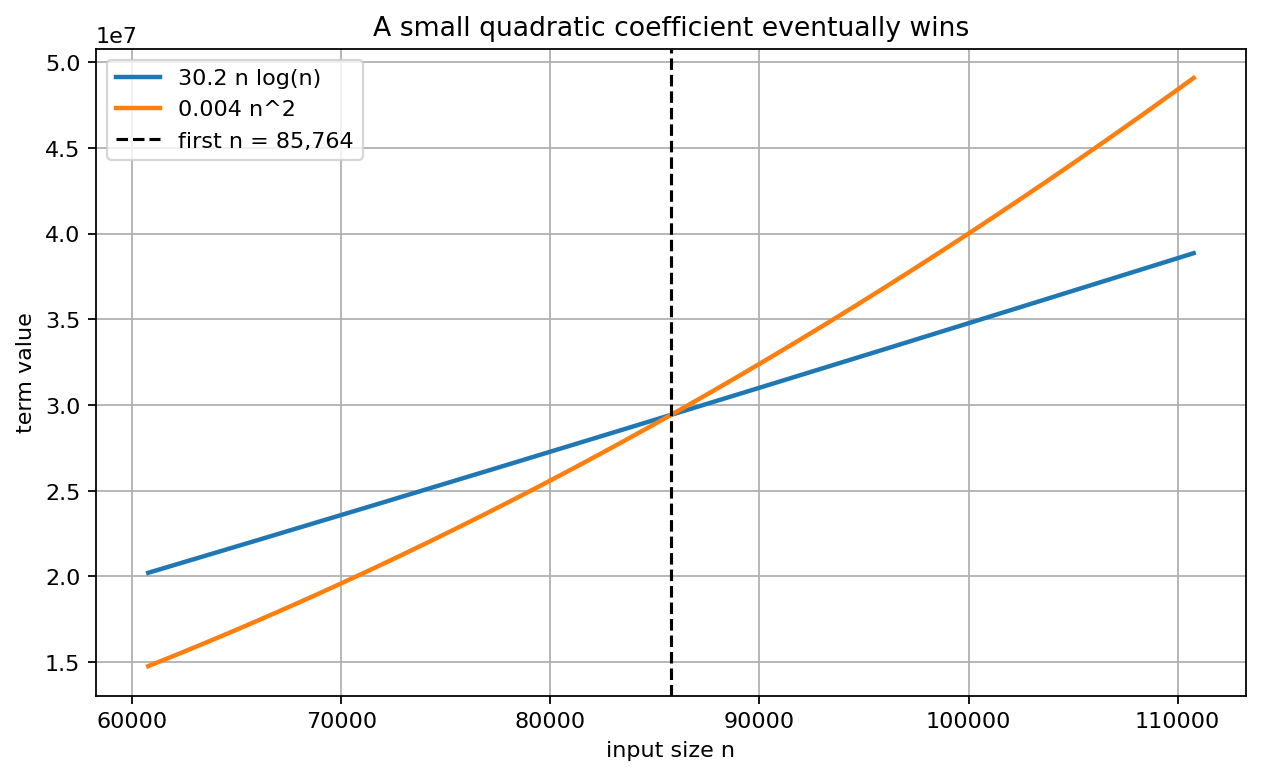

First integer crossover using natural log: **85,764**.

In [3]:
def first_quadratic_wins(limit=1_000_000):
    values = np.arange(2, limit + 1, dtype=float)
    nlogn = 30.2 * values * np.log(values)
    quad = 0.004 * values**2
    winners = np.flatnonzero(quad > nlogn)
    if winners.size == 0:
        raise RuntimeError('increase search limit')
    return int(values[winners[0]])

crossover_n = first_quadratic_wins()
window = np.arange(max(2, crossover_n - 25_000), crossover_n + 25_001)
nlogn_term = 30.2 * window * np.log(window)
quad_term = 0.004 * window**2

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(window, nlogn_term, label='30.2 n log(n)', linewidth=2)
ax.plot(window, quad_term, label='0.004 n^2', linewidth=2)
ax.axvline(crossover_n, color='black', linestyle='--', linewidth=1.4, label=f'first n = {crossover_n:,}')
ax.set_title('A small quadratic coefficient eventually wins')
ax.set_xlabel('input size n')
ax.set_ylabel('term value')
ax.legend()
fig.tight_layout()

crossover_plot = save_matplotlib(fig, FIGURES / 'quadratic-crossover-lab.png')
plt.close(fig)
artifact_paths.append(crossover_plot)

nearby = []
for sample in [crossover_n - 2, crossover_n - 1, crossover_n, crossover_n + 1, crossover_n * 2]:
    sample = int(sample)
    nearby.append({
        'n': sample,
        '30.2*n*ln(n)': 30.2 * sample * math.log(sample),
        '0.004*n^2': 0.004 * sample**2,
        'quadratic_exceeds': bool(0.004 * sample**2 > 30.2 * sample * math.log(sample)),
    })
crossover_table = save_csv(nearby, TABLES / 'quadratic-crossover-neighborhood.csv')
crossover_check = save_json({
    'log_convention': 'natural logarithm',
    'first_integer_where_0.004_n2_exceeds_30.2_n_logn': crossover_n,
    'previous_integer_exceeds': bool(0.004 * (crossover_n - 1)**2 > 30.2 * (crossover_n - 1) * math.log(crossover_n - 1)),
    'crossover_integer_exceeds': bool(0.004 * crossover_n**2 > 30.2 * crossover_n * math.log(crossover_n)),
    'base_note': 'Changing log base changes the numeric threshold but not the asymptotic comparison.',
}, CHECKS / 'quadratic-crossover-checks.json')
artifact_paths.extend([crossover_table, crossover_check])

display_artifact(crossover_plot, width=820)
display(Markdown(f'First integer crossover using natural log: **{crossover_n:,}**.'))


## Upper Bounds, Lower Bounds, and Tightness

An upper bound belongs to an algorithm: it says the construction will finish within a certain growth envelope. A lower bound belongs to a problem within a model: it says no algorithm in that model can always do better. When those meet, the result is asymptotically optimal. This distinction is central in computational geometry because a pretty construction and a proof of unavoidable cost are different kinds of knowledge.

The table below is a compact reading guide for the whole book. It is intentionally phrased as modeling advice: identify the input, name the construction, say which comparison model or reduction is being used, then ask whether the known upper and lower bounds match.


In [4]:
bound_rows = [
    {'role': 'upper bound', 'asks': 'How much work does this algorithm use?', 'evidence': 'loop count, recurrence, data-structure operations', 'geometry_example': 'incremental hull construction'},
    {'role': 'lower bound', 'asks': 'Can every algorithm be forced to spend this much work?', 'evidence': 'comparison tree, reduction, adversarial input family', 'geometry_example': 'sorting-style lower bound for hull ordering'},
    {'role': 'tight bound', 'asks': 'Do the upper and lower bounds meet?', 'evidence': 'matching O and Omega statements', 'geometry_example': 'optimal comparison-based geometric sorting tasks'},
    {'role': 'hardness result', 'asks': 'Does a known hard problem transform into this one?', 'evidence': 'polynomial reduction preserving yes/no answers', 'geometry_example': 'chain folding and guard-placement variants'},
]
bound_table = save_csv(bound_rows, TABLES / 'bounds-tightness-reading-guide.csv')
bound_check = save_json({
    'roles_present': [row['role'] for row in bound_rows],
    'has_upper_lower_tight': {'upper bound', 'lower bound', 'tight bound'}.issubset({row['role'] for row in bound_rows}),
}, CHECKS / 'bounds-tightness-checks.json')
artifact_paths.extend([bound_table, bound_check])

display(Markdown('`bounds-tightness-reading-guide.csv` records the distinction between algorithm analysis and problem lower bounds.'))


`bounds-tightness-reading-guide.csv` records the distinction between algorithm analysis and problem lower bounds.

## Reductions and Hardness as a Directed Graph

Hardness proofs are directional. If a known hard problem can be transformed into a new problem quickly, then a fast solver for the new problem would also solve the old one quickly. That is why the arrow direction matters. The graph below treats complexity classes and geometric examples as nodes; the checks verify that the geometric examples are reachable from the reduction story rather than isolated labels.


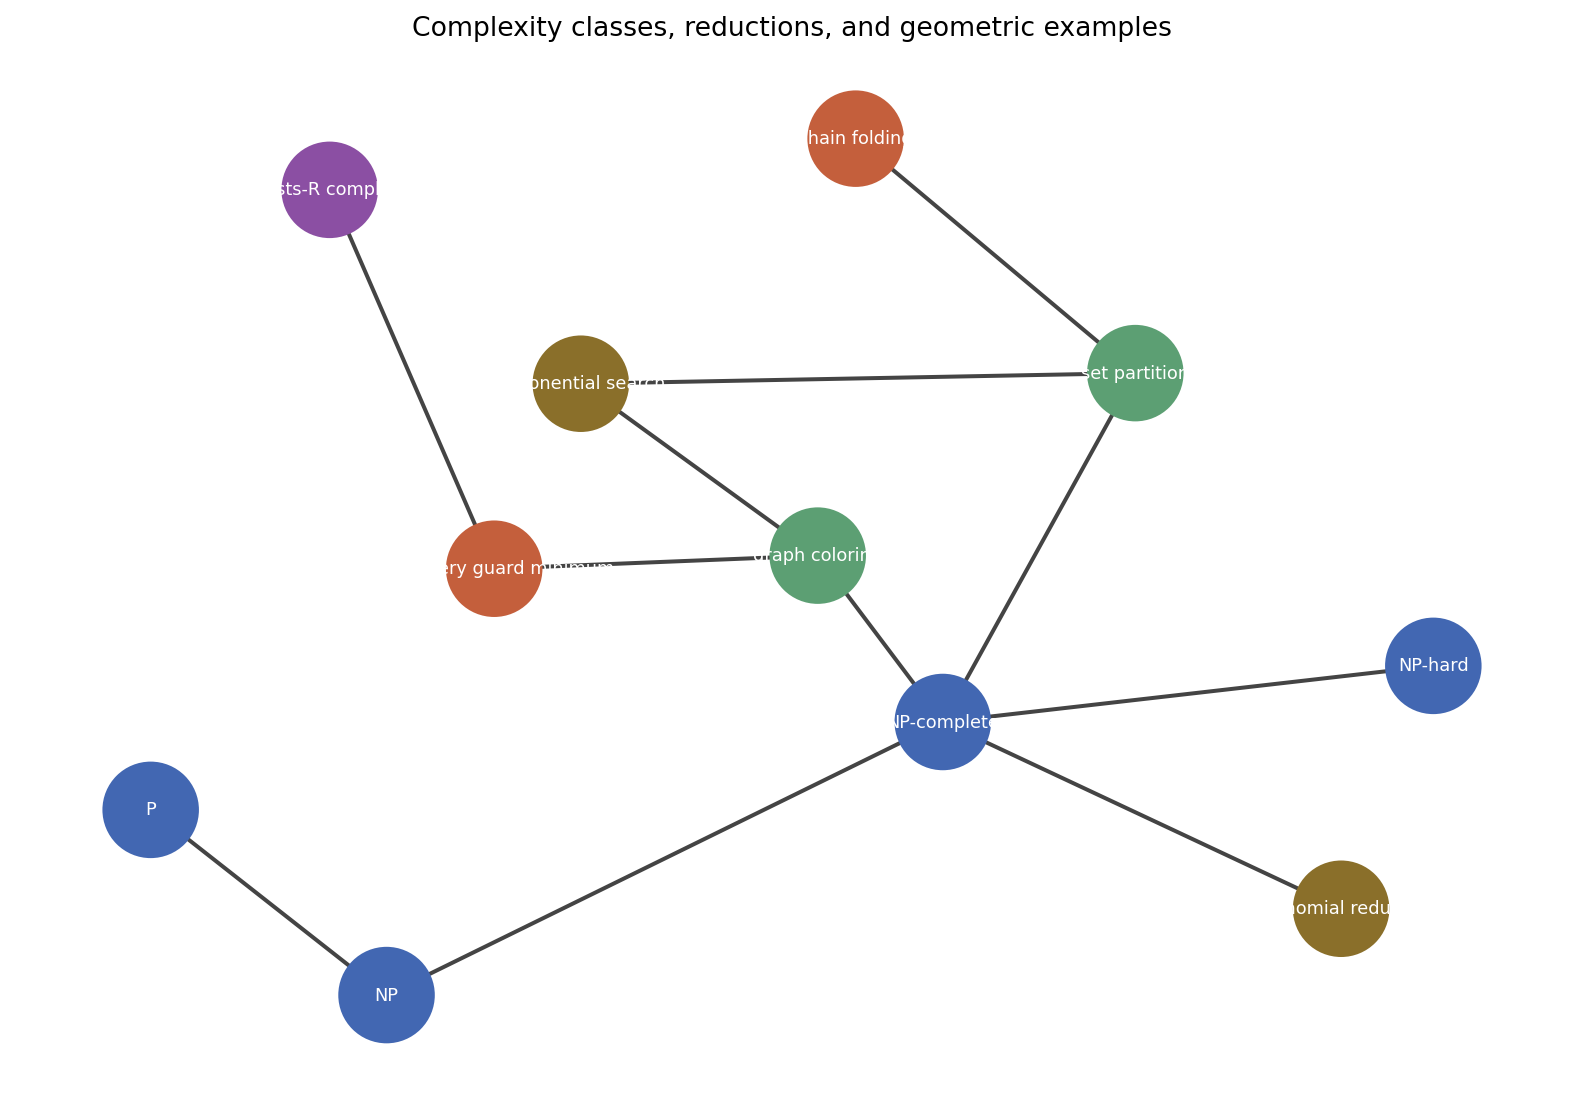

In [5]:
G = nx.DiGraph()
node_groups = {
    'P': 'class',
    'NP': 'class',
    'NP-complete': 'class',
    'NP-hard': 'class',
    'exponential search': 'method',
    'polynomial reduction': 'method',
    'set partition': 'source problem',
    'graph coloring': 'source problem',
    'chain folding': 'geometry problem',
    'art gallery guard minimum': 'geometry problem',
    'exists-R complete': 'real-algebraic hardness',
}
G.add_nodes_from(node_groups)
G.add_edges_from([
    ('P', 'NP'),
    ('NP-complete', 'NP'),
    ('NP-complete', 'NP-hard'),
    ('set partition', 'NP-complete'),
    ('graph coloring', 'NP-complete'),
    ('polynomial reduction', 'NP-complete'),
    ('set partition', 'chain folding'),
    ('graph coloring', 'art gallery guard minimum'),
    ('art gallery guard minimum', 'exists-R complete'),
    ('exponential search', 'graph coloring'),
    ('exponential search', 'set partition'),
])

colors = {
    'class': '#4267b2',
    'method': '#8a6f2a',
    'source problem': '#5c9f73',
    'geometry problem': '#c45f3c',
    'real-algebraic hardness': '#8b4fa3',
}
pos = nx.spring_layout(G, seed=17, k=1.1)
fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(G, pos, node_color=[colors[node_groups[n]] for n in G.nodes], node_size=1800, ax=ax)
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=18, width=1.8, edge_color='#444444', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', ax=ax)
ax.set_title('Complexity classes, reductions, and geometric examples')
ax.axis('off')
fig.tight_layout()

hardness_plot = save_matplotlib(fig, FIGURES / 'complexity-reduction-map.png')
plt.close(fig)
artifact_paths.append(hardness_plot)

reduction_edges = [{'source': u, 'target': v} for u, v in G.edges]
reduction_table = save_csv(reduction_edges, TABLES / 'complexity-reduction-edges.csv')
reduction_check = save_json({
    'node_count': G.number_of_nodes(),
    'edge_count': G.number_of_edges(),
    'chain_folding_has_np_complete_source': bool(nx.has_path(G, 'set partition', 'chain folding')),
    'guard_problem_reaches_real_algebraic_class': bool(nx.has_path(G, 'art gallery guard minimum', 'exists-R complete')),
    'graph_coloring_reaches_np_hard': bool(nx.has_path(G, 'graph coloring', 'NP-hard')),
}, CHECKS / 'complexity-reduction-map-checks.json')
artifact_paths.extend([reduction_table, reduction_check])

display_artifact(hardness_plot, width=900)


## Course Complexity Ledger

The appendix is useful only if it changes how we read the chapters. The ledger below links the major constructions back to the cost language. Some entries are algorithmic, such as hulls and Voronoi diagrams. Some are proof-theoretic, such as Euler or Gauss-Bonnet, where complexity is not the main point but finite checks still depend on the size of a combinatorial structure. Some are hardness signposts: the chain-folding chapter and the art-gallery material show how natural geometric questions can move past straightforward polynomial algorithms.


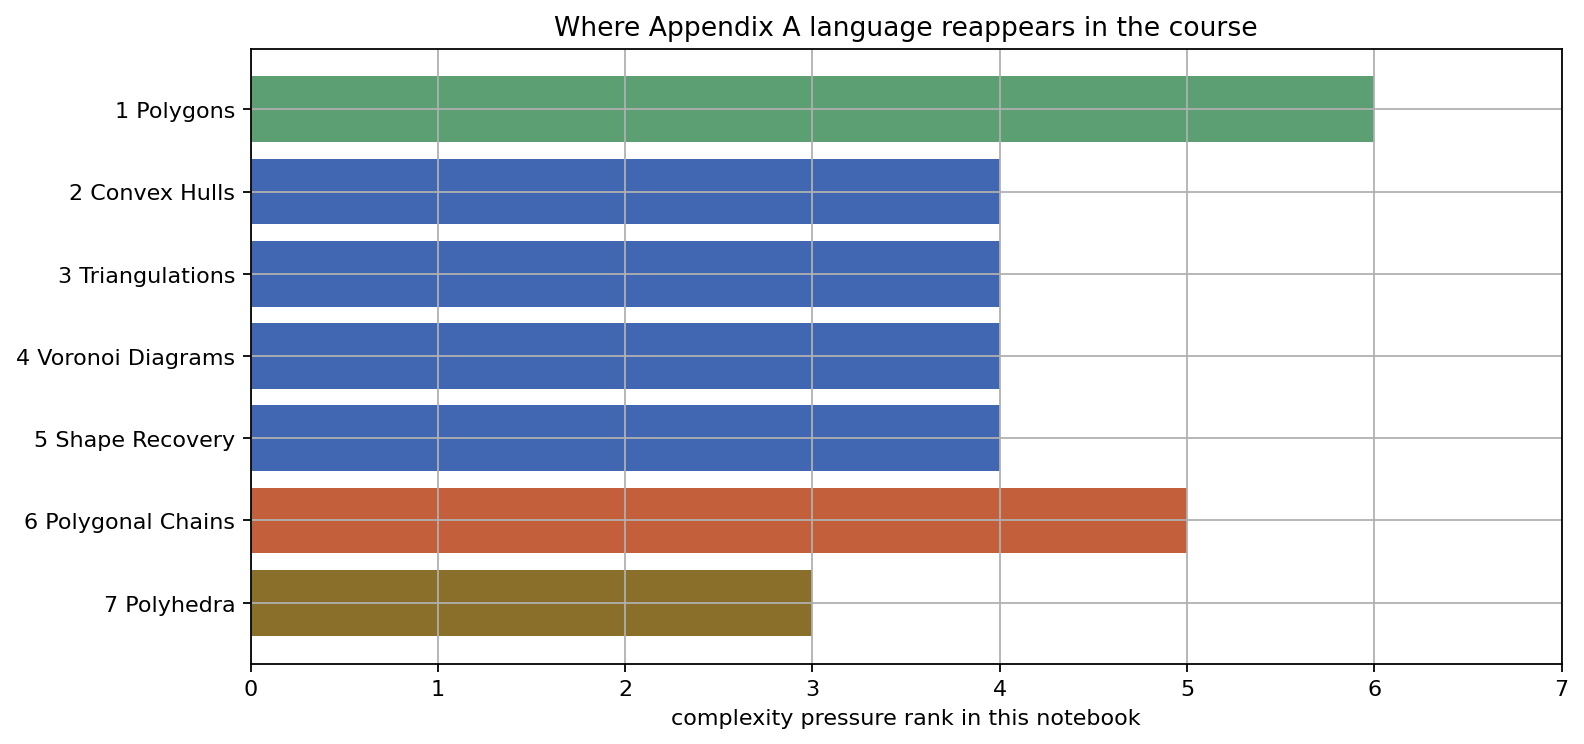

Course ledger: `artifacts\appendix-a-computational-complexity\tables\dcg-chapter-complexity-ledger.csv`

In [6]:
ledger_rows = [
    {'chapter': '1 Polygons', 'input_size': 'polygon vertices', 'construction_or_question': 'triangulation, 3-coloring guards, optimal guards', 'typical_order_or_class': 'linear to polynomial for constructive proofs; optimal guards can be exists-R complete', 'rank': 6},
    {'chapter': '2 Convex Hulls', 'input_size': 'points', 'construction_or_question': 'incremental hull, gift wrapping, Graham scan, divide-and-conquer', 'typical_order_or_class': 'O(n^2), O(nh), O(n log n)', 'rank': 4},
    {'chapter': '3 Triangulations', 'input_size': 'points or polygon vertices', 'construction_or_question': 'triangulation, flips, Delaunay, MST inclusion', 'typical_order_or_class': 'often O(n log n) for Delaunay; flip graphs may be large', 'rank': 4},
    {'chapter': '4 Voronoi Diagrams', 'input_size': 'sites', 'construction_or_question': 'Voronoi cells, Delaunay dual, lower hull lifting', 'typical_order_or_class': 'O(n log n) algorithms and linear-size planar output under assumptions', 'rank': 4},
    {'chapter': '5 Shape Recovery', 'input_size': 'samples', 'construction_or_question': 'Crust and alpha complex via Delaunay thresholding', 'typical_order_or_class': 'Delaunay-dominated plus filtration checks', 'rank': 4},
    {'chapter': '6 Polygonal Chains', 'input_size': 'links and degrees of freedom', 'construction_or_question': 'reachability, folding, motion planning', 'typical_order_or_class': 'polynomial for fixed-DOF models; folding decision problems can be NP-complete', 'rank': 5},
    {'chapter': '7 Polyhedra', 'input_size': 'vertices, edges, faces', 'construction_or_question': 'Euler checks, curvature ledgers, unfolding, shortest paths', 'typical_order_or_class': 'finite graph/surface size controls verification; some unfolding questions remain difficult', 'rank': 3},
]
ledger_table = save_csv(ledger_rows, TABLES / 'dcg-chapter-complexity-ledger.csv')

fig, ax = plt.subplots(figsize=(10, 4.8))
chapters = [row['chapter'] for row in ledger_rows]
ranks = [row['rank'] for row in ledger_rows]
bar_colors = ['#5c9f73', '#4267b2', '#4267b2', '#4267b2', '#4267b2', '#c45f3c', '#8a6f2a']
ax.barh(chapters, ranks, color=bar_colors)
ax.set_xlim(0, 7)
ax.set_xlabel('complexity pressure rank in this notebook')
ax.set_title('Where Appendix A language reappears in the course')
ax.invert_yaxis()
ax.set_xticks(range(0, 8))
fig.tight_layout()
ledger_plot = save_matplotlib(fig, FIGURES / 'dcg-chapter-complexity-ledger.png')
plt.close(fig)
artifact_paths.extend([ledger_table, ledger_plot])

coverage_items = [
    'Big-O upper bounds and dominant terms',
    'Polynomial versus exponential growth',
    'Big-Omega lower bounds and tightness',
    'Decision-tree/comparison-model lower-bound idea',
    'NP, NP-complete, and NP-hard verification versus search',
    'Polynomial reductions from known hard problems',
    'Graph coloring and set partition as reference problems',
    'Chain folding as a geometric hardness example',
    'Art-gallery guard minimization and exists-R complete geometry',
    'Course-wide routing back to hulls, triangulations, Voronoi diagrams, reconstruction, chains, and polyhedra',
]
coverage = save_json({
    'source_span_read': 'printed pages 253-258, PDF pages 268-273',
    'coverage_items': coverage_items,
    'chapter_rows': len(ledger_rows),
    'all_chapters_represented': len(ledger_rows) == 7,
}, CHECKS / 'source-coverage.json')
artifact_paths.append(coverage)

display_artifact(ledger_plot, width=900)
display(Markdown(f'Course ledger: `{ledger_table.relative_to(BOOK_ROOT)}`'))


## Applied Lab

Use the artifacts above as a decision workflow for a new geometric algorithm:

1. Name the input size precisely: points, vertices, links, faces, or degrees of freedom.
2. Separate the algorithm's operations from the theorem's mathematical claim.
3. Estimate an upper bound from the visible loops, recursive splits, predicate calls, or graph operations.
4. Ask whether a lower bound or reduction is available. If the problem has real-valued coordinates, ask whether a combinatorial encoding is losing information.
5. Check moderate inputs before making practical claims; constants can decide what is usable long before asymptotics take over.

A good notebook answer should therefore include both a plot and a proof ledger. The plot shows what happens at sizes a learner can see; the ledger records what survives when the input grows beyond the plotted window.


In [7]:
lab_rows = []
for n_value in [50, 500, 5_000, 50_000, 500_000]:
    lab_rows.append({
        'n': n_value,
        'binary_search_log2_n': math.log2(n_value),
        'sorting_n_log2_n': n_value * math.log2(n_value),
        'incremental_hull_quadratic_proxy': n_value**2,
        'bruteforce_2_to_n_display_cap': 'too large' if n_value > 60 else 2**n_value,
    })
lab_table = save_csv(lab_rows, TABLES / 'practical-input-size-lab.csv')
lab_check = save_json({
    'sample_sizes': [row['n'] for row in lab_rows],
    'quadratic_exceeds_sorting_at_largest_sample': bool(lab_rows[-1]['incremental_hull_quadratic_proxy'] > lab_rows[-1]['sorting_n_log2_n']),
    'logarithmic_less_than_linear_at_all_samples': bool(all(row['binary_search_log2_n'] < row['n'] for row in lab_rows)),
}, CHECKS / 'practical-input-size-lab-checks.json')
artifact_paths.extend([lab_table, lab_check])

display(Markdown(f'Practical input-size lab table: `{lab_table.relative_to(BOOK_ROOT)}`'))


Practical input-size lab table: `artifacts\appendix-a-computational-complexity\tables\practical-input-size-lab.csv`

## Takeaways

- Complexity is a modeling language: always state what `n` counts before comparing algorithms.
- Big-O gives an eventual upper envelope; Big-Omega gives a problem lower constraint; tightness means those two stories meet.
- A small coefficient can delay the crossover, but it cannot change which term dominates asymptotically.
- Polynomial reductions turn hardness into a geometric proof tool: if a fast solver for the new problem would solve a known hard problem, the new problem inherits that difficulty evidence.
- The book's constructive chapters and its harder decision problems belong in the same notebook course because geometry needs both algorithms and impossibility evidence.


In [8]:
# final_sanity
assert growth_check['monotone_checks']['O(log n)']
assert crossover_n > 2
assert not json.loads(crossover_check.read_text())['previous_integer_exceeds']
assert json.loads(crossover_check.read_text())['crossover_integer_exceeds']
assert nx.has_path(G, 'set partition', 'chain folding')
assert nx.has_path(G, 'art gallery guard minimum', 'exists-R complete')
assert len(ledger_rows) == 7
assert len(coverage_items) >= 9
assert_artifacts(artifact_paths, min_bytes=64)
final_sanity = {
    'artifact_count': len(artifact_paths),
    'crossover_n_natural_log': crossover_n,
    'chapters_represented': len(ledger_rows),
    'coverage_items': len(coverage_items),
    'status': 'passed',
}
final_sanity_path = save_json(final_sanity, CHECKS / 'final-sanity.json')
assert_artifacts([final_sanity_path], min_bytes=64)
final_sanity


{'artifact_count': 16,
 'crossover_n_natural_log': 85764,
 'chapters_represented': 7,
 'coverage_items': 10,
 'status': 'passed'}